### Importing Libraries

---

In [1]:
import os
import sys
import time
import tempfile
import joblib
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from mlflow.data import from_pandas
from mlflow.tracking import MlflowClient
from mlflow.models import infer_signature

from churnlabs.core.config import PROJECT_ROOT

### Warnings Configuration

---

In [2]:
# Suppress MLflow Warnings Only
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")
warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")

### MLflow Configuration

---

In [3]:
# This sets the tracking URI for MLflow
# Instead of using the default local ./mlruns folder,
# It configure MLflow to use a SQLite database stored inside the project directory
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}")

### Custom Seaborn Plot Style

---

In [4]:
# This snippet allow us to create a custom style of plots in Seaborn
sns.set_style('ticks')
sns.set_theme('paper')

### Loading the Data

---

In [5]:
# Importing load_processed_data function from loaders module
from churnlabs.data.loaders import load_processed_data
churn_data = load_processed_data()
churn_data.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,29.850000,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950001,1889.500000,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.849998,108.150002,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.299999,1840.750000,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.699997,151.649994,Yes


### Copy of Original DataFrame

---

In [6]:
# Making a copy of Original DataFrame
df = churn_data.copy()

### Splitting the Data

---

In [7]:
# Splitting Data into Training and Testing Set
from churnlabs.features.split import split_data
X_train, X_test, y_train, y_test = split_data(df)
print(f"Training Data : {X_train.shape[0]} | Testing Data : {X_test.shape[0]}")

Training Data : 5625 | Testing Data : 1407


### Encoding Target Variable

---

In [8]:
# Encoding Target Variable (Yes/No -> 1/0)
from churnlabs.models.encoder import target_encoder
y_train, y_test = target_encoder(y_train, y_test)

### Building Preprocessing Pipeline

---

In [9]:
# Importing Libraries
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
# Importing Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [11]:
# Transformation for Categorical Columns
cat_cols = X_train.select_dtypes(include='category').columns

cat_trf = Pipeline(steps=[
    ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'))
])

In [12]:
# Transformation for Numerical Columns
num_cols = [col for col in X_train.select_dtypes(include='number').columns if col != 'seniorcitizen']

num_trf = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [13]:
# Combining Everything into ColumnTransformer
ctf = ColumnTransformer(transformers=[
    ('categorical', cat_trf, cat_cols),
    ('numerical', num_trf, num_cols)
], remainder='passthrough', n_jobs=-1)

### Training a Baseline Model

---

In [14]:
# Importing DummyClassifier Model
dummy = DummyClassifier(strategy='most_frequent', random_state=42)

In [15]:
# Pipeline
pipe = Pipeline(steps=[
    ('preprocessor', ctf),
    ('model', dummy)
])

In [16]:
# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
# Cross-Validation Setup
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1_score': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv = cross_validate(estimator=pipe, X=X_train, y=y_train, cv=skf, scoring=scoring, n_jobs=-1)

In [18]:
# Cross-Validation Result
results = {metric.replace('test_', ''): [np.mean(scores), np.std(scores)] for metric, scores in cv.items() if metric.startswith('test')}
results_df = pd.DataFrame(results, index=['mean', 'std']).T
results_df

,mean,std
accuracy,0.734222,0.0
precision,0.000000,0.0
recall,0.000000,0.0
f1_score,0.000000,0.0
roc_auc,0.500000,0.0
pr_auc,0.265778,0.0


**What does the `DummyClassifier` tell us?**
- The Dummy Classifier gives us a baseline to compare against real models.
- It predicts the majority class (non-churn) for every customer, ignoring all features.
```
# Class Distribution
churn
No     0.7342
Yes    0.2657
```
```
# Classification Metrics
accuracy    73%
precision   0
recall      0
f1_score    0
roc_auc     0.5
pr_auc      0.26
```
- Since the dataset contains ~73% non-churn customers, the model achieves 73% accuracy.
- However, it fails to identify any churners, resulting in zero precision, recall, and F1-Score.
- A model that never identifies a churner is useless, making recall and PR-AUC the only metrics that matter.
- ROC-AUC of 0.5 and PR-AUC of 0.26 confirm no predictive power, performing equivalent to random guessing.
- The Dummy Classifier makes exactly the same prediction in every fold.
- So every fold produces identical metrics, and that's why standard deviation is equal to 0.
- This confirms our pipeline and cross-validation setup behave as expected.
- Now any real model must surpass this benchmark to be considered a good performer.
```
# Real Model Expectations
Achieve PR-AUC > 0.26
Achieve ROC-AUC > 0.5
Achieve Precision > 0
Achieve Recall > 0
Achieve F1-Score > 0
```
- If a trained model cannot outperform this baseline, it is not useful.

### Multi-Model Comparison

---

In [19]:
# Define the name of the MLflow Experiment
experiment_name = 'model_comparison'

# Define the location of Model Artifacts and Dataset
artifact_location = PROJECT_ROOT / 'mlartifacts'
dataset_location = PROJECT_ROOT / 'data' / 'processed' / 'customer-churn-processed.parquet'

# Experiment-level Metadata
experiment_tags = {
    'project': 'customer_churn_prediction',
    'problem_type': 'binary_classification',
    'business_metric': 'recall',
    'validation_strategy': 'stratified_5_fold',
    'dataset_path': str(dataset_location),
    'stage': 'experimentation',
    'python_version': sys.version.split()[0],
    'os': platform.system()
}

# Check if the experiment already exists, and create the experiment if it doesn't exist
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None or experiment.lifecycle_stage == 'deleted':
    experiment_id = mlflow.create_experiment(
        name=experiment_name,
        artifact_location=f"file:///{artifact_location}",
        tags=experiment_tags
    )
else:
    experiment_id = experiment.experiment_id

# Set as Active Experiment, where all subsequent mlflow.start_run() calls will be logged under this experiment
mlflow.set_experiment(experiment_name)

2026/07/02 17:26:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/02 17:26:26 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///C:\\Users\\iamri\\Videos\\churnlabs\\mlartifacts', creation_time=1782993387558, experiment_id='1', last_update_time=1782993387558, lifecycle_stage='active', name='model_comparison', tags={'business_metric': 'recall',
 'dataset_path': 'C:\\Users\\iamri\\Videos\\churnlabs\\data\\processed\\customer-churn-processed.parquet',
 'os': 'Windows',
 'problem_type': 'binary_classification',
 'project': 'customer_churn_prediction',
 'python_version': '3.11.14',
 'stage': 'experimentation',
 'validation_strategy': 'stratified_5_fold'}, workspace='default'>

In [20]:
# Initialize MLflow client
client = MlflowClient()

# Experiment Description (Visible in MLflow UI)
experiment_description = """
**Experiment**
- Model Comparison

**Objective**
- Evaluate and compare multiple machine learning models for predicting customer churn.
- Model selection based on Recall and PR-AUC given class imbalance in dataset.
- Validated using Stratified 5-Fold Cross-Validation.

**Evaluation Metrics**
- Accuracy
- Precision
- Recall (Business Metric)
- F1-Score
- ROC-AUC
- PR-AUC
"""

# Attach Experiment Description
client.set_experiment_tag(
    experiment_id,
    'mlflow.note.content',
    experiment_description.strip()
)

In [21]:
# Multi-Model Dictionary 
models = {
    'DC': DummyClassifier(strategy='most_frequent', random_state=42),
    'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_jobs=-1),
    'SVC': SVC(class_weight='balanced', probability=True, random_state=42),
    'DT': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RF': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'GB': GradientBoostingClassifier(random_state=42)
}

In [22]:
# Dictionary to store aggregated CV results for all models
final_results = {}

# Loop through each model defined in the models dictionary
for name, model in models.items():

    # Start a new MLflow run for each model
    with mlflow.start_run(
        run_name=name,
        description=f"MLflow run for '{name}' using Stratified 5-Fold Cross-Validation",
        tags={
            'project': 'customer_churn_prediction',
            'phase': 'experimentation',
            'experiment_type': 'model_comparison',
            'problem_type': 'binary_classification',
            'business_metric': 'recall'
        },
        log_system_metrics=True
    ):

        # Log Dataset Information
        dataset = from_pandas(
            churn_data,
            source=str(dataset_location),
            name='customer_churn_data',
            targets='churn',
        )
        mlflow.log_input(dataset, context='training')

        # Build Pipeline
        pipe = Pipeline(steps=[
            ('preprocessor', ctf),
            ('model', model)
        ])

        # Cross Validation
        start_time = time.time()
        cv = cross_validate(
            estimator=pipe,
            X=X_train,
            y=y_train,
            cv=skf,
            scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision'],
            n_jobs=-1
        )
        runtime = time.time() - start_time
        mlflow.log_metric('cv_runtime_sec', runtime)

        # Log Fold Metrics
        for metric, scores in cv.items():
            if metric.startswith('test_'):
                metric_name = metric.replace('test_', '').replace('average_precision', 'pr_auc').replace('f1', 'f1_score')
                for fold_idx, score in enumerate(scores):
                    mlflow.log_metric(key=f"{metric_name}_fold", value=score, step=fold_idx)

        # Log Aggregated Metrics
        results = {}
        for metric, scores in cv.items():
            if metric.startswith('test_'):
                metric_name = metric.replace('test_', '').replace('average_precision', 'pr_auc').replace('f1', 'f1_score')
                mean_score = np.mean(scores)
                results[f"{metric_name}_mean"] = mean_score
                mlflow.log_metric(f"{metric_name}_mean", mean_score)

        final_results[name] = results

        # Log Model Info
        mlflow.log_param('model_type', model.__class__.__name__)
        mlflow.log_param('cv_folds', 5)
        for param_name, param_value in model.get_params().items():
            if isinstance(param_value, (int, float, str, bool)):
                mlflow.log_param(param_name, param_value)

        # Log Each Fitted Model
        # Cast int64 to float64 because MLflow signature inference fails on int64 columns
        pipe.fit(X_train, y_train)
        X_train_for_mlflow = X_train.copy()
        int_cols = X_train_for_mlflow.select_dtypes(include=['int64']).columns
        X_train_for_mlflow[int_cols] = X_train_for_mlflow[int_cols].astype('float64')

        signature = infer_signature(X_train_for_mlflow, pipe.predict(X_train_for_mlflow))
        input_example = X_train_for_mlflow.iloc[:5]

        mlflow.sklearn.log_model(
            sk_model=pipe,
            name=name,
            serialization_format='cloudpickle',
            signature=signature,
            input_example=input_example,
            metadata={
                'problem_type': 'binary_classification',
                'target': 'churn',
                'business_metric': 'recall',
                'cv_folds': 5,
            },
            tags={
                'model_family': model.__class__.__name__,
                'project': 'customer_churn_prediction',
            },
            model_type='sklearn_classifier',
        )

# Metrics Table
results_df = pd.DataFrame(final_results)

2026/07/02 17:26:32 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:26:33 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:26:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:26:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/07/02 17:26:51 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:26:51 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/02 17:26:51 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:26:51 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:26:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:26:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/07/02 17:26:57 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:26:57 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/02 17:26:57 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:26:57 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:27:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:27:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/07/02 17:27:06 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:27:06 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/02 17:27:06 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:27:06 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:27:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:27:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/07/02 17:27:23 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:27:23 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/02 17:27:23 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:27:23 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:27:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:27:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/07/02 17:27:28 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:27:28 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/02 17:27:28 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:27:28 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:27:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:27:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/07/02 17:27:33 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:27:33 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/02 17:27:33 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:27:33 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:27:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:27:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to c

2026/07/02 17:27:39 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:27:39 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [23]:
# Plotting Metric Comparision Graph
for model in results_df.columns:
    print()
    print(f'Model : {model}')
    print('-' * 40)
    print(f'Recall    : {results_df.loc["recall_mean", model]:.2f}')
    print(f'PR-AUC    : {results_df.loc["pr_auc_mean", model]:.2f}')
    print(f'ROC-AUC   : {results_df.loc["roc_auc_mean", model]:.2f}')
    print(f'F1-Score  : {results_df.loc["f1_score_mean", model]:.2f}')
    print(f'Precision : {results_df.loc["precision_mean", model]:.2f}')
    print(f'Accuracy  : {results_df.loc["accuracy_mean", model]:.2f}')


Model : DC
----------------------------------------
Recall    : 0.00
PR-AUC    : 0.27
ROC-AUC   : 0.50
F1-Score  : 0.00
Precision : 0.00
Accuracy  : 0.73

Model : LR
----------------------------------------
Recall    : 0.80
PR-AUC    : 0.66
ROC-AUC   : 0.85
F1-Score  : 0.63
Precision : 0.52
Accuracy  : 0.75

Model : KNN
----------------------------------------
Recall    : 0.53
PR-AUC    : 0.52
ROC-AUC   : 0.78
F1-Score  : 0.55
Precision : 0.56
Accuracy  : 0.77

Model : SVC
----------------------------------------
Recall    : 0.79
PR-AUC    : 0.60
ROC-AUC   : 0.83
F1-Score  : 0.62
Precision : 0.52
Accuracy  : 0.75

Model : DT
----------------------------------------
Recall    : 0.49
PR-AUC    : 0.38
ROC-AUC   : 0.65
F1-Score  : 0.49
Precision : 0.50
Accuracy  : 0.73

Model : RF
----------------------------------------
Recall    : 0.47
PR-AUC    : 0.63
ROC-AUC   : 0.83
F1-Score  : 0.55
Precision : 0.64
Accuracy  : 0.79

Model : GB
----------------------------------------
Recall    : 0.5

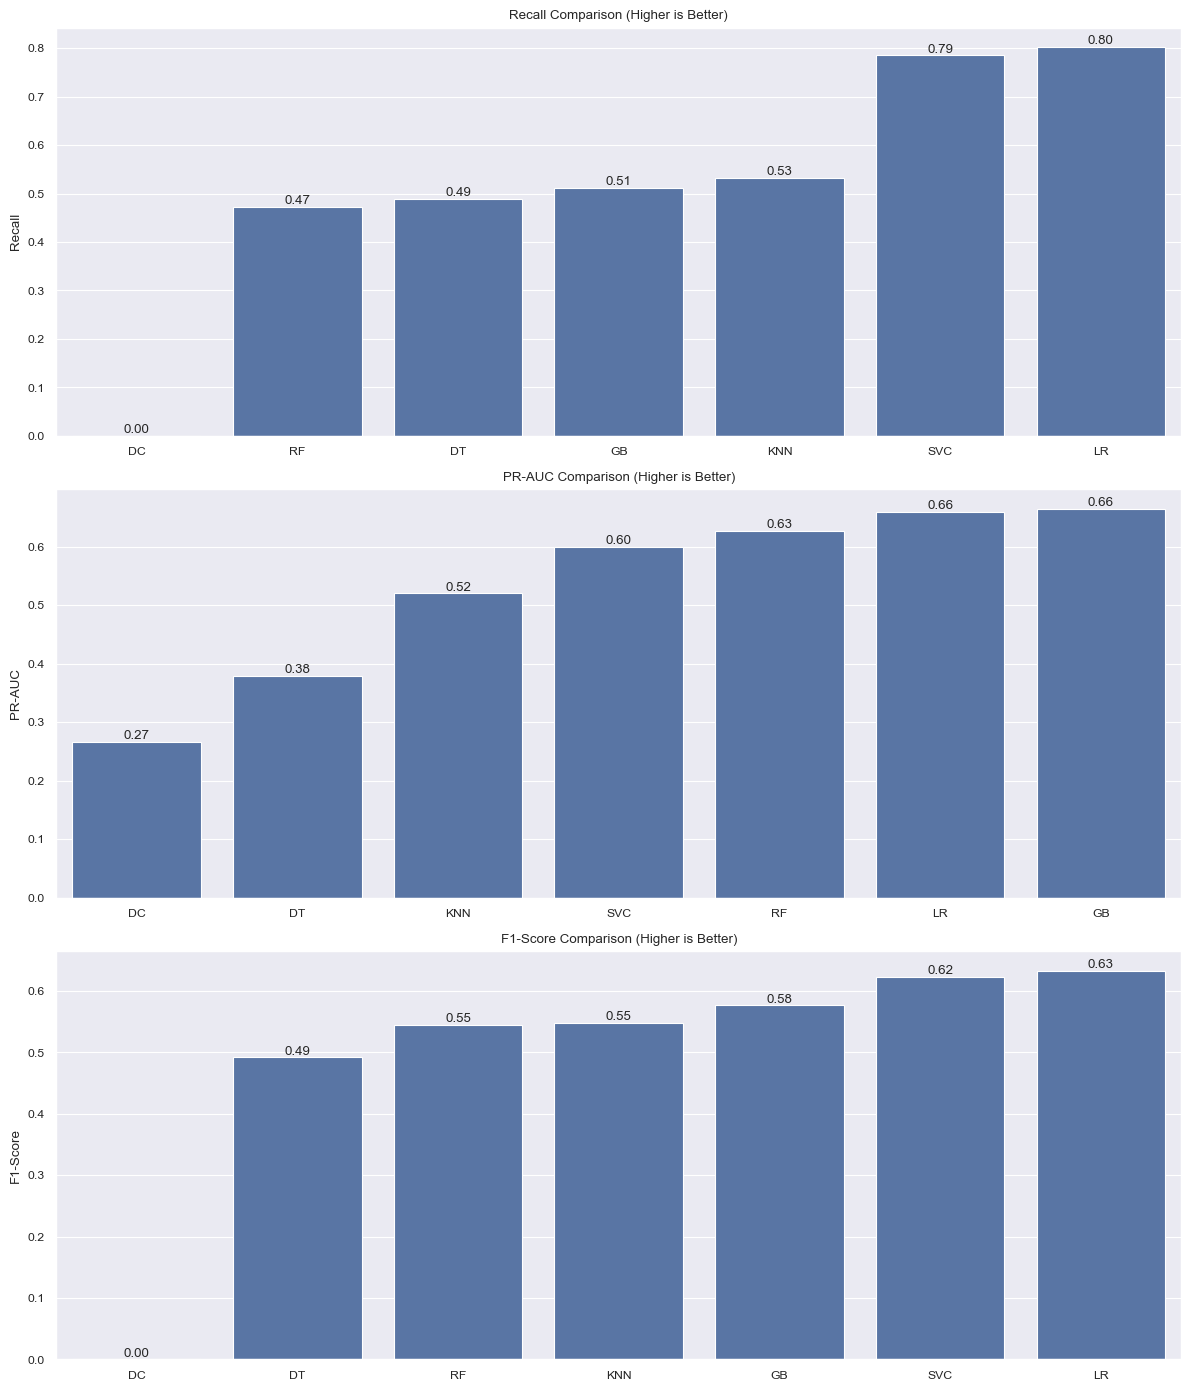

In [24]:
# Plotting Metric Comparison Graph
recall_sorted = results_df.loc['recall_mean',:].sort_values()
pr_auc_sorted = results_df.loc['pr_auc_mean',:].sort_values()
f1_sorted = results_df.loc["f1_score_mean",:].sort_values()

fig, ax = plt.subplots(ncols=1, nrows=3, figsize=(12, 14))

sns.barplot(x=recall_sorted.index.to_list(), y=recall_sorted.values, ax=ax[0])
ax[0].set_title('Recall Comparison (Higher is Better)')
ax[0].set_ylabel('Recall')
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f')

sns.barplot(x=pr_auc_sorted.index.to_list(), y=pr_auc_sorted.values, ax=ax[1])
ax[1].set_title('PR-AUC Comparison (Higher is Better)')
ax[1].set_ylabel('PR-AUC')
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.2f')

sns.barplot(x=f1_sorted.index.to_list(), y=f1_sorted.values, ax=ax[2])
ax[2].set_title('F1-Score Comparison (Higher is Better)')
ax[2].set_ylabel('F1-Score')
for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Selecting `LogisticRegression` as Final Model

---

- The above graph shows model performance based on recall and PR-AUC, since churn is an imbalanced problem where accuracy alone can be misleading.
- The Dummy Classifier baseline achieves 0.73 accuracy but 0.00 recall, precision, and F1 confirming that accuracy is not a reliable metric for this dataset.
- Logistic Regression and Gradient Boosting stand out as the top two models :
    - Both achieve the same PR-AUC (0.66) and ROC-AUC (0.85), meaning they rank churners equally well.
    - LR achieves a much higher recall (0.80) than GB (0.51), catching significantly more actual churners.
    - GB edges ahead on precision (0.66 vs 0.52) and accuracy (0.80 vs 0.75), but at the cost of missing more churners.
- Logistic Regression is selected as the final model because :
    - It matches GB's ranking ability, so no predictive quality is lost by choosing it.
    - Its higher recall aligns with the business priority missing a churner is more costly than sending an unnecessary retention offer.
    - It is simpler and more interpretable than an ensemble model like GB, making it easier to explain and justify to stakeholders.

In [25]:
# Creating LogisticRegression Model Object
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [26]:
# Final Pipeline with LogisticRegression
pipe = Pipeline(steps=[
        ('preprocessor', ctf),
        ('model', lr)
    ])

In [27]:
# Cross-Validation Predict
y_pred_cv = cross_val_predict(estimator=pipe, X=X_train, y=y_train, cv=skf, method='predict', n_jobs=-1)

In [28]:
# Classification Report
print(classification_report(y_train, y_pred_cv, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      4130
         Yes       0.52      0.80      0.63      1495

    accuracy                           0.75      5625
   macro avg       0.72      0.77      0.72      5625
weighted avg       0.81      0.75      0.77      5625



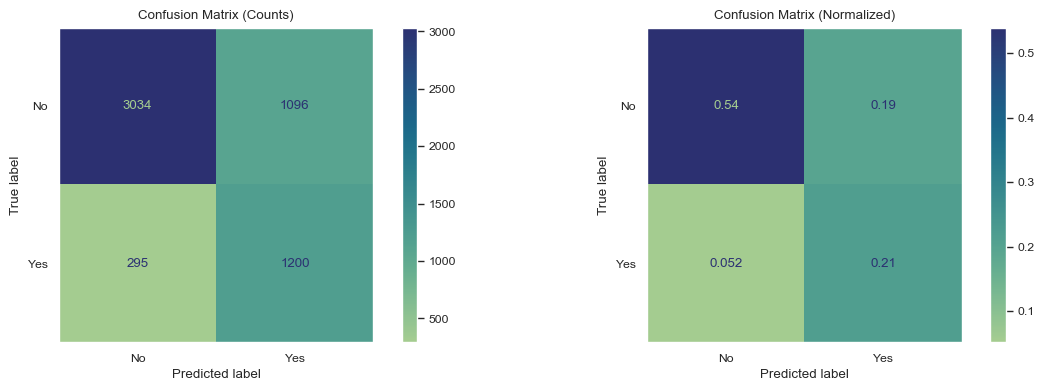

In [29]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_true=y_train, y_pred=y_pred_cv, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_true=y_train, y_pred=y_pred_cv, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix (Counts)')
ax[1].set_title('Confusion Matrix (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()

**What does the confusion matrix tell us?**
- The confusion matrix shows how the default Logistic Regression model's predictions compare against actual outcomes.
- Out of 4,130 actual non-churners, 3,034 are correctly predicted as "No" (True Negatives), while 1,096 are incorrectly predicted as "Yes" (False Positives).
- Out of 1,495 actual churners, 1,200 are correctly predicted as "Yes" (True Positives), while 295 are incorrectly predicted as "No" (False Negatives).
- The normalized matrix shows only 5.2% of all customers are missed churners (False Negatives), compared to 19% flagged incorrectly (False Positives).
- This means the model leans toward over-predicting churn rather than under-predicting it.
- Missing a churner is more costly than a false alarm, since a missed churner represents a customer who leaves without any retention attempt.
- So this imbalance of more false alarms, fewer missed churners aligns with the business priority of not letting actual churners slip through.

### Feature Importance

---

In [30]:
# Fitting the Pipeline
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [31]:
# Raw Column Names from ColumnTransformer (like 'numerical__totalcharges')
raw_features = pipe.named_steps['preprocessor'].get_feature_names_out()

In [32]:
# Clean Column Names (splitting based on '__' and extracting 2nd element)
features = [feature.split('__')[1] for feature in raw_features]

In [33]:
# Coefficients from LogisticRegression
coefficients = pipe.named_steps['model'].coef_[0]

In [34]:
# Feature Importance DataFrame
importance_df = pd.DataFrame({'feature': features, 'importance': coefficients}).sort_values(by='importance', ascending=False)

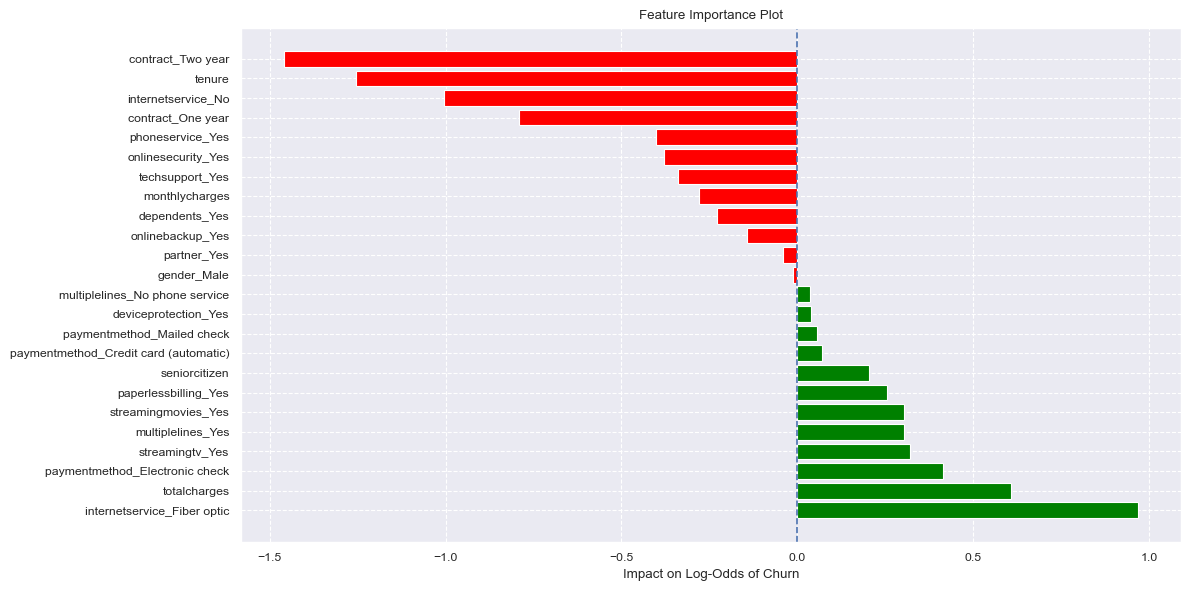

In [35]:
# Feature Importance Plot
plt.figure(figsize=(12, 6))
colors = ['green' if val > 0 else 'red' for val in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Impact on Log-Odds of Churn')
plt.title('Feature Importance Plot')
plt.axvline(0, linestyle='--')
plt.grid(axis='both', linestyle='--', alpha=1)
plt.tight_layout()
plt.show()

**Feature Importance Interpretation**
- 🟢 Positive coefficients → Increase churn risk
- 🔴 Negative coefficients → Decrease churn risk

**What does the feature importance plot tell us?**
- The plot shows each feature's impact on the log-odds of churn from the Logistic Regression coefficients.
- Red bars represent features that reduce the likelihood of churn :
    - "contract_Two year" has the strongest negative impact, followed by "tenure" and "internetservice_No".
    - Customers on longer contracts or with more tenure are far less likely to churn.
    - "contract_One year", "phoneservice_Yes", and "onlinesecurity_Yes" also reduce churn likelihood, though to a lesser degree.
- Green bars represent features that increase the likelihood of churn :
    - "internetservice_Fiber optic" has the strongest positive impact, followed by "totalcharges" and "paymentmethod_Electronic check".
    - "streamingtv_Yes", "multiplelines_Yes", and "streamingmovies_Yes" also push customers toward higher churn risk.
- This pattern suggests that contract commitment and tenure are the biggest protective factors,
- While fiber optic service and electronic check payments are the strongest risk indicators.
- These insights align with common churn intuition, customers locked into longer contracts are less likely to leave,
- While those on flexible, higher-cost services show higher churn risk.

### Decision Threshold Tuning

---

In [36]:
# Cross-Validation Predict
y_proba_cv = cross_val_predict(estimator=pipe, X=X_train, y=y_train, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

In [37]:
# Compute Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_train, y_proba_cv)

In [38]:
# Align Threshold with Precision/Recall
pr_results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})
pr_results

,threshold,precision,recall
0,0.002917,0.265778,1.000000
1,0.002934,0.265825,1.000000
2,0.003030,0.265872,1.000000
3,0.003401,0.265920,1.000000
4,0.003428,0.265967,1.000000
...,...,...,...
5608,0.936657,1.000000,0.003344
5609,0.939382,1.000000,0.002676
5610,0.940971,1.000000,0.002007
5611,0.941039,1.000000,0.001338


In [39]:
# Define a Recall Target (Business Decision)
recall_target = 0.90

In [40]:
# Evaluate Recall across Thresholds and Choose Best Threshold
valid = pr_results[pr_results["recall"] >= recall_target]

if not valid.empty:
    best_row = valid.loc[valid["precision"].idxmax()]
    best_threshold = best_row["threshold"]
else:
    best_threshold = 0.5
    print("Warning: No threshold achieved target recall of 0.90. Falling back to 0.5.")

print(f"Best Threshold: {best_threshold:.4f}")

Best Threshold: 0.3632


### Performance Evaluation with Tuned Threshold

---

In [41]:
# Best Threshold
y_pred_best = (y_proba_cv >= best_threshold).astype(int)

In [42]:
# Classification Report
print(classification_report(y_train, y_pred_best, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.95      0.61      0.74      4130
         Yes       0.45      0.90      0.60      1495

    accuracy                           0.69      5625
   macro avg       0.70      0.76      0.67      5625
weighted avg       0.81      0.69      0.70      5625



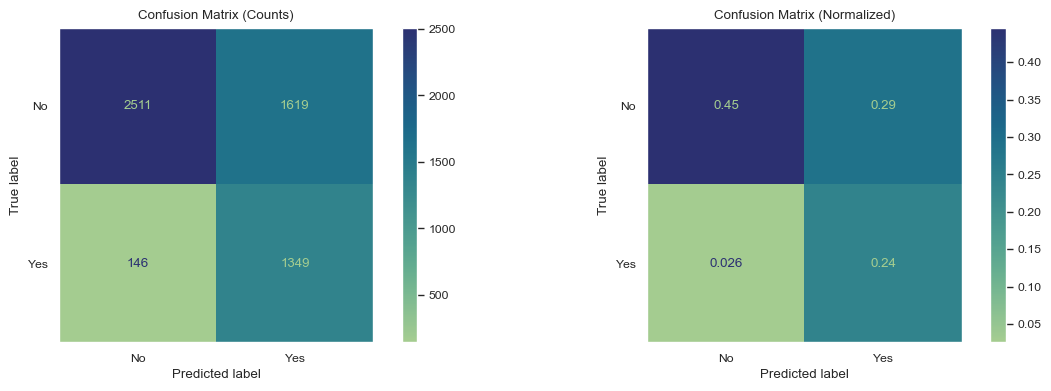

In [43]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_best, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_best, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix (Counts)')
ax[1].set_title('Confusion Matrix (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()

**What does the confusion matrix tell us after threshold tuning?**
- The confusion matrix shows the Logistic Regression model's performance after lowering the decision threshold from 0.5 to 0.3632.
- Out of 1,495 actual churners, 1,349 are now correctly identified, up from 1,200 at the default threshold, missed churners drop from 295 to 146.
- Out of 4,130 actual non-churners, correctly predicted "No" drops from 3,034 to 2,511, while false alarms rise from 1,096 to 1,619.
- The normalized matrix shows missed churners fall from 5.2% to 2.6%, while false alarms rise from 19% to 29%.
- This confirms the intended trade-off, lowering the threshold sacrifices precision to catch more churners,
- Since missing a churner is costlier than an unnecessary retention offer.
- Accepting lower precision is only justified when the cost of a retention offer is genuinely small compared to the cost of losing a customer entirely.
- If retention offers were expensive, the extra 523 false alarms introduced by tuning would carry real cost, and the threshold would need to be re-evaluated.
- So the choice of 0.3632 isn't universally "correct", it depends entirely on the actual cost of a false positive versus a false negative,
- Which should be validated with real retention-cost data before deployment.

### Threshold Optimization MLflow Experiment

---

In [44]:
# Define the name of the MLflow Experiment
experiment_name = 'threshold_optimization'

# Experiment-level Metadata
experiment_tags = {
    'project': 'customer_churn_prediction',
    'problem_type': 'binary_classification',
    'business_metric': 'recall',
    'validation_strategy': 'stratified_5_fold',
    'dataset_path': str(dataset_location),
    'stage': 'threshold_optimization',
    'python_version': sys.version.split()[0],
    'os': platform.system()
}

# Check if the experiment already exists, and create the experiment if it doesn't exist
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None or experiment.lifecycle_stage == 'deleted':
    experiment_id = mlflow.create_experiment(
        name=experiment_name,
        artifact_location=f"file:///{artifact_location}",
        tags=experiment_tags
    )
else:
    experiment_id = experiment.experiment_id

# Set as Active Experiment, where all subsequent mlflow.start_run() calls will be logged under this experiment
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///C:\\Users\\iamri\\Videos\\churnlabs\\mlartifacts', creation_time=1782993521204, experiment_id='2', last_update_time=1782993521204, lifecycle_stage='active', name='threshold_optimization', tags={'business_metric': 'recall',
 'dataset_path': 'C:\\Users\\iamri\\Videos\\churnlabs\\data\\processed\\customer-churn-processed.parquet',
 'os': 'Windows',
 'problem_type': 'binary_classification',
 'project': 'customer_churn_prediction',
 'python_version': '3.11.14',
 'stage': 'threshold_optimization',
 'validation_strategy': 'stratified_5_fold'}, workspace='default'>

In [45]:
# Initialize MLflow Client
client = MlflowClient()

# Experiment Description (Visible in MLflow UI)
experiment_description = """
**Experiment**
- Threshold Optimization

**Objective**
- Optimize performance of Logistic Regression Model using a recall-optimized decision threshold.
- Achieve ≥90% recall on the churn class while maximizing precision within that constraint.
- Compare the default threshold with tuned threshold to quantify the improvement.

**Evaluation Metrics**
- Accuracy
- Precision
- Recall (Business Metric)
- F1-Score
- ROC-AUC
- PR-AUC
"""

# Attach Experiment Description
client.set_experiment_tag(
    experiment_id,
    'mlflow.note.content',
    experiment_description.strip()
)

2026/07/02 17:28:41 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:28:41 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:28:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:28:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/07/02 17:28:46 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:28:46 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


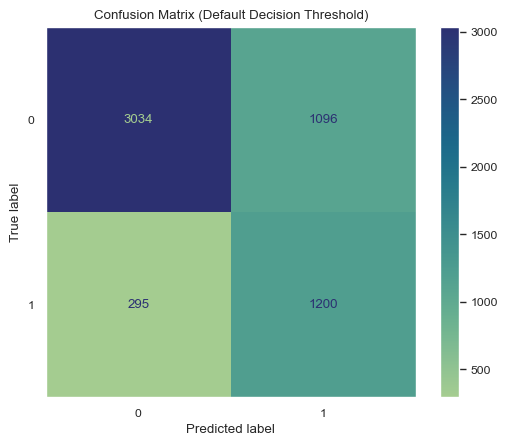

In [46]:
# Run 1 : Default Decision Threshold
with mlflow.start_run(
    run_name='default_decision_threshold',
    description='Validation run for Logistic Regression with Default Decision Threshold',
    tags={
        'project': 'customer_churn_prediction',
        'phase': 'validation',
        'threshold_type': 'default',
        'problem_type': 'binary_classification',
        'business_metric': 'recall'
    },
    log_system_metrics=True
):
    # Log Model Info
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('random_state', 42)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('decision_threshold', 0.5)

    # Log Dataset Information
    dataset = from_pandas(
        churn_data,
        source=str(dataset_location),
        name='customer_churn_data',
        targets='churn',
    )

    mlflow.log_input(dataset, context='training')

    # Default Threshold Metrics (0.5)
    y_pred_default = (y_proba_cv >= 0.5).astype(int)
    mlflow.log_metric('accuracy', np.mean(y_pred_default == y_train))
    mlflow.log_metric('precision', precision_score(y_train, y_pred_default))
    mlflow.log_metric('recall', recall_score(y_train, y_pred_default))
    mlflow.log_metric('f1_score', f1_score(y_train, y_pred_default))

    # ROC AUC (Threshold-Independent)
    mlflow.log_metric('roc_auc', roc_auc_score(y_train, y_proba_cv))
    mlflow.log_metric('pr_auc', average_precision_score(y_train, y_proba_cv))

    # Classification Report
    report_default = classification_report(y_train, y_pred_default, target_names=['No', 'Yes'])
    with open('classification_report_default.txt', 'w') as f:
        f.write(report_default)
    mlflow.log_artifact('classification_report_default.txt', artifact_path='reports')

    # Confusion Matrix (Default Threshold)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_default, cmap='crest')
    plt.title('Confusion Matrix (Default Decision Threshold)')
    plt.grid(visible=False)
    plt.savefig('confusion_matrix_default.png')
    mlflow.log_artifact('confusion_matrix_default.png', artifact_path='plots')
    plt.close(fig)

    # Log Final Fitted Model
    # Cast int64 to float64 because MLflow signature inference fails on int64 columns
    pipe.fit(X_train, y_train)
    
    X_train_for_mlflow = X_train.copy()

    int_cols = X_train_for_mlflow.select_dtypes(include=['int64']).columns
    X_train_for_mlflow[int_cols] = X_train_for_mlflow[int_cols].astype('float64')

    signature = infer_signature(X_train_for_mlflow, pipe.predict(X_train_for_mlflow))
    input_example = X_train_for_mlflow.iloc[:5]  

    mlflow.sklearn.log_model(
        sk_model=pipe,
        name='logistic_regression_default_decision_threshold',
        serialization_format='cloudpickle',
        signature=signature,
        input_example=input_example,
        metadata={
                'problem_type': 'binary_classification',
                'target': 'churn',
                'business_metric': 'recall',
                'cv_folds': 5,
                'decision_threshold': 0.5
            },
            tags={
                'model_family': 'LogisticRegression',
                'project': 'customer_churn_prediction',
            },
            model_type='sklearn_classifier',
    )

2026/07/02 17:28:46 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/02 17:28:46 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/02 17:28:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/02 17:28:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/07/02 17:28:50 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/02 17:28:50 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


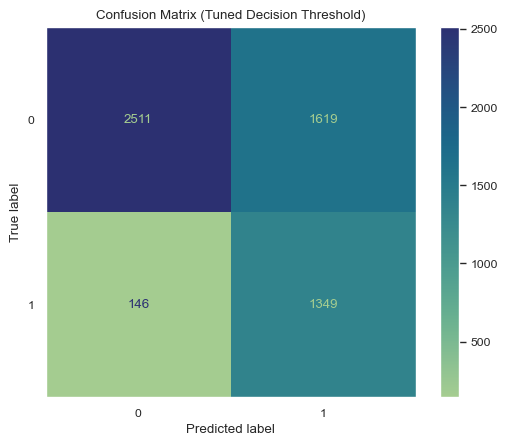

In [47]:
# Run 2 : Tuned Decision Threshold
with mlflow.start_run(
    run_name='tuned_decision_threshold',
    description='Validation run for Logistic Regression with Tuned Decision Threshold',
    tags={
        'project': 'customer_churn_prediction',
        'phase': 'validation',
        'threshold_type': 'tuned',
        'problem_type': 'binary_classification',
        'business_metric': 'recall'
    },
    log_system_metrics=True
):
    # Log Model Info
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('random_state', 42)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('decision_threshold', float(best_threshold))

    # Log Dataset Information
    dataset = from_pandas(
        churn_data,
        source=str(dataset_location),
        name='customer_churn_data',
        targets='churn',
    )

    mlflow.log_input(dataset, context='training')

    # Tuned Threshold Metrics
    y_pred_tuned = (y_proba_cv >= best_threshold).astype(int)
    mlflow.log_metric('accuracy', np.mean(y_pred_tuned == y_train))
    mlflow.log_metric('precision', precision_score(y_train, y_pred_tuned))
    mlflow.log_metric('recall', recall_score(y_train, y_pred_tuned))
    mlflow.log_metric('f1_score', f1_score(y_train, y_pred_tuned))

    # ROC-AUC (Threshold-Independent)
    mlflow.log_metric('roc_auc', roc_auc_score(y_train, y_proba_cv))
    mlflow.log_metric('pr_auc', average_precision_score(y_train, y_proba_cv))

    # Classification Report
    report_tuned = classification_report(y_train, y_pred_tuned, target_names=['No', 'Yes'])
    with open('classification_report_tuned.txt', 'w') as f:
        f.write(report_tuned)
    mlflow.log_artifact('classification_report_tuned.txt', artifact_path='reports')

    # Confusion Matrix (Tuned Threshold)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tuned, cmap='crest')
    plt.title('Confusion Matrix (Tuned Decision Threshold)')
    plt.grid(visible=False)
    plt.savefig('confusion_matrix_tuned.png')
    mlflow.log_artifact('confusion_matrix_tuned.png', artifact_path='plots')
    plt.close(fig)

    # Log Final Fitted Model
    # Cast int64 to float64 because MLflow signature inference fails on int64 columns
    pipe.fit(X_train, y_train)
    
    X_train_for_mlflow = X_train.copy()

    int_cols = X_train_for_mlflow.select_dtypes(include=['int64']).columns
    X_train_for_mlflow[int_cols] = X_train_for_mlflow[int_cols].astype('float64')

    signature = infer_signature(X_train_for_mlflow, pipe.predict(X_train_for_mlflow))
    input_example = X_train_for_mlflow.iloc[:5]     

    mlflow.sklearn.log_model(
        sk_model=pipe,
        name='logistic_regression_tuned_decision_threshold',
        serialization_format='cloudpickle',
        signature=signature,
        input_example=input_example,
        metadata={
                'problem_type': 'binary_classification',
                'target': 'churn',
                'business_metric': 'recall',
                'cv_folds': 5,
                'decision_threshold': float(best_threshold)
            },
            tags={
                'model_family': 'LogisticRegression',
                'project': 'customer_churn_prediction',
            },
            model_type='sklearn_classifier',
    )

### Final Model Evaluation on Test Set

---

In [48]:
# Fitting Pipeline on Full Training Data
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [49]:
# Test Set Probability used for both Default and Tuned Threshold
y_test_proba = pipe.predict_proba(X_test)[:, 1]

In [50]:
# Default Threshold
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

In [51]:
# Classification Report on Default Threshold
print(classification_report(y_test, y_test_pred_default, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



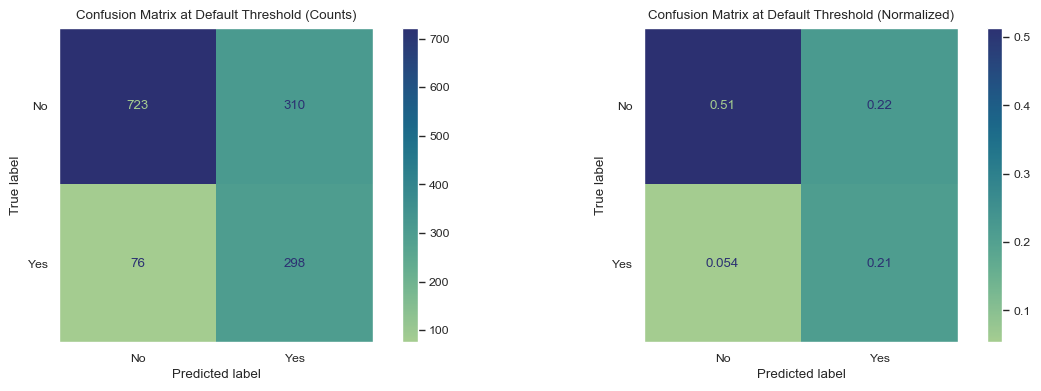

In [52]:
# Plotting Confusion Matrix on Default Threshold
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_default, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_default, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix at Default Threshold (Counts)')
ax[1].set_title('Confusion Matrix at Default Threshold (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()

---

In [53]:
# Tuned Threshold
y_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)

In [54]:
# Classification Report on Tuned Threshold
print(classification_report(y_test, y_test_pred_tuned, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.94      0.58      0.71      1033
         Yes       0.43      0.90      0.58       374

    accuracy                           0.66      1407
   macro avg       0.69      0.74      0.65      1407
weighted avg       0.80      0.66      0.68      1407



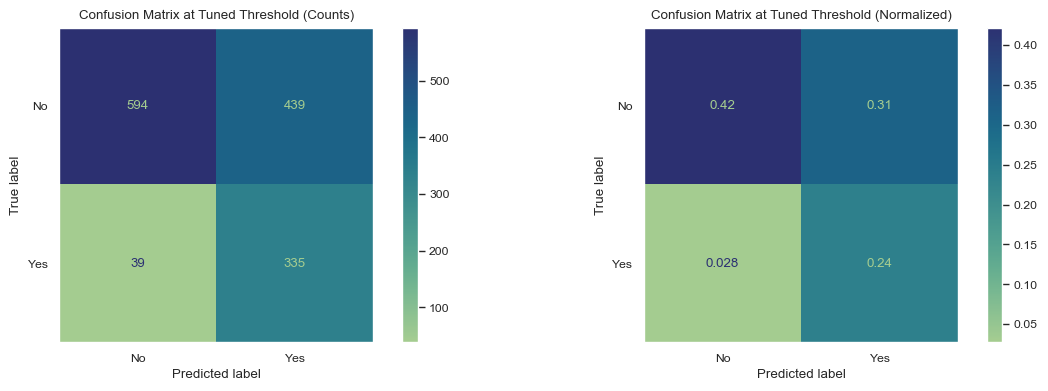

In [55]:
# Plotting Confusion Matrix on Tuned Threshold
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tuned, display_labels=['No', 'Yes'], cmap='crest', ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tuned, display_labels=['No', 'Yes'], cmap='crest', normalize='all', ax=ax[1])
ax[0].set_title('Confusion Matrix at Tuned Threshold (Counts)')
ax[1].set_title('Confusion Matrix at Tuned Threshold (Normalized)')
ax[0].grid(visible=False)
ax[1].grid(visible=False)
plt.tight_layout()
plt.show()

**What does the test set confusion matrix tell us?**
- Both matrices show performance on the held-out test set (unseen data), evaluated once after the model and threshold were finalized on training data.
```
# Default Threshold (0.5) - Test Set
                Predicted No   Predicted Yes
Actual No       723            310
Actual Yes      76             298
```
```
# Tuned Threshold (0.3632) - Test Set
                Predicted No   Predicted Yes
Actual No       594            439
Actual Yes      39             335
```
- At the default threshold, 298 of 374 churners are correctly identified (recall = 0.80), with 76 missed.
- At the tuned threshold, this improves to 335 of 374 churners correctly identified (recall = 0.90), with only 39 missed.
- This matches the recall improvement seen on the training data, confirming the threshold tuning generalizes well to unseen data.
- The trade-off is the same as before, false alarms rise from 310 to 439, dropping precision from 49% to 43%.
- The consistency between CV and test set results (same recall gain, same precision trade-off) confirms no overfitting occurred during threshold selection.